# Feature Selection


In [3]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("data_set_feature_engineered.csv")
df

,age,gender,income,experience_years,monthly_spending,credit_score,has_credit_card,loan_amount,defaulted,city_Unknown,...,education_PhD,education_Unknown,signup_year,signup_month,signup_day,signup_dayofweek,employment_type_Government,employment_type_Private,employment_type_Student,employment_type_Unemployed
0,18.0,1,97203.41,33,34323.67,728.0,1,162409.81000,0,0,...,0,0,2020,1,1,2,0,0,0,1
1,56.0,0,132084.64,20,36955.51,439.0,1,207532.68000,0,0,...,0,0,2020,2,1,5,1,0,0,0
2,51.0,0,39789.24,26,30520.91,516.0,1,261934.54000,0,0,...,0,0,2020,3,1,6,1,0,0,0
3,21.0,0,110957.74,23,34385.96,520.0,0,247704.90777,1,0,...,0,0,2020,4,1,2,0,0,1,0
4,69.0,0,127385.88,18,34126.80,715.0,0,92532.55000,0,0,...,0,0,2020,5,1,4,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2427,62.0,0,101994.71,33,24921.03,479.0,0,148220.46000,0,1,...,0,0,2026,8,12,2,0,0,0,0
2428,36.0,1,85476.33,4,30555.01,735.0,1,216758.02000,0,0,...,0,0,2024,2,15,3,0,0,0,0
2429,27.0,1,55062.67,2,45068.89,501.0,0,443914.49000,0,0,...,0,0,2024,2,15,3,0,0,1,0
2430,74.0,1,71753.00,7,25897.50,613.0,0,444756.20000,0,0,...,0,0,2025,6,15,6,0,1,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2432 entries, 0 to 2431
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         2432 non-null   float64
 1   gender                      2432 non-null   int64  
 2   income                      2432 non-null   float64
 3   experience_years            2432 non-null   int64  
 4   monthly_spending            2432 non-null   float64
 5   credit_score                2432 non-null   float64
 6   has_credit_card             2432 non-null   int64  
 7   loan_amount                 2432 non-null   float64
 8   defaulted                   2432 non-null   int64  
 9   city_Unknown                2432 non-null   int64  
 10  city_faisalabad             2432 non-null   int64  
 11  city_islamabad              2432 non-null   int64  
 12  city_karachi                2432 non-null   int64  
 13  city_rawalpindi             2432 non-null   

In [6]:
corr = df.corr(numeric_only=True)

print(corr["defaulted"].sort_values(ascending=False))

defaulted                     1.000000
loan_amount                   0.114304
has_credit_card               0.045134
income                        0.034642
city_rawalpindi               0.034225
signup_day                    0.032011
signup_year                   0.024360
signup_month                  0.021981
education_Matric              0.021625
employment_type_Government    0.016916
city_karachi                  0.015073
education_Master              0.003150
city_Unknown                  0.002391
age                          -0.000849
employment_type_Unemployed   -0.000926
employment_type_Student      -0.007851
monthly_spending             -0.010956
gender                       -0.012625
education_PhD                -0.012671
city_islamabad               -0.012704
signup_dayofweek             -0.014634
employment_type_Private      -0.018173
education_Unknown            -0.024839
experience_years             -0.025430
education_Intermediate       -0.029326
city_faisalabad          

In [7]:
numeric_cols = [
    "age",
    "income",
    "experience_years",
    "monthly_spending",
    "credit_score",
    "loan_amount"
]

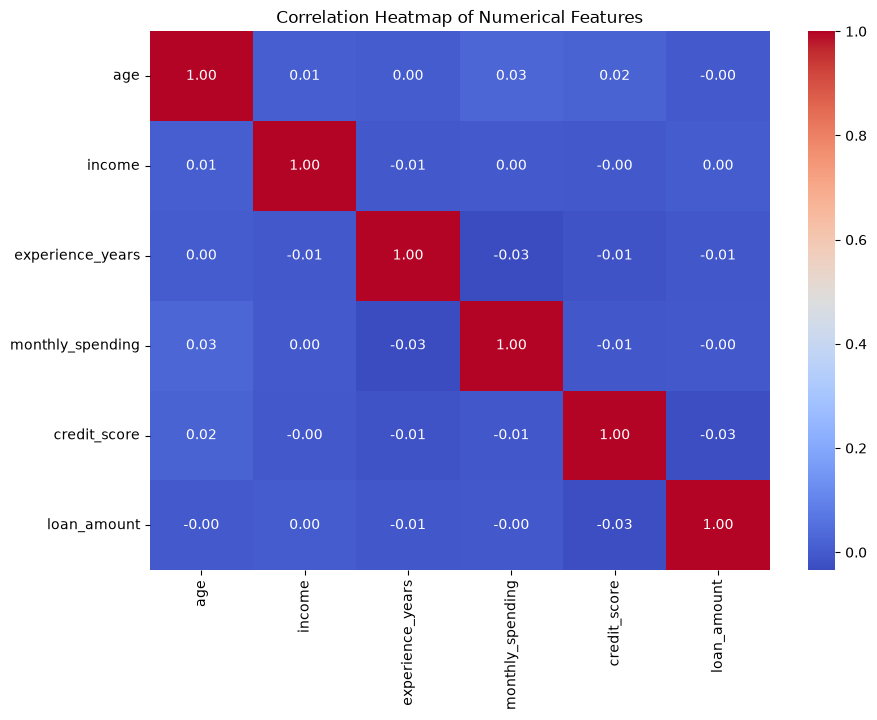

In [8]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [9]:
X = df.drop("defaulted", axis=1)
y = df["defaulted"]

In [10]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_scores = pd.Series(mi_scores, index=X.columns)

mi_scores = mi_scores.sort_values(ascending=False)

print(mi_scores)

credit_score                  0.030538
loan_amount                   0.022771
employment_type_Government    0.012046
education_Intermediate        0.007224
signup_day                    0.006940
city_islamabad                0.006667
employment_type_Private       0.005461
signup_year                   0.005167
education_Master              0.004934
has_credit_card               0.004829
city_karachi                  0.000048
gender                        0.000014
city_faisalabad               0.000000
city_Unknown                  0.000000
income                        0.000000
age                           0.000000
experience_years              0.000000
monthly_spending              0.000000
education_Unknown             0.000000
education_PhD                 0.000000
education_Matric              0.000000
city_rawalpindi               0.000000
signup_dayofweek              0.000000
signup_month                  0.000000
employment_type_Student       0.000000
employment_type_Unemploye

In [11]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

categorical_cols = [
    "gender",
    "has_credit_card",
    "city_Unknown",
    "city_faisalabad",
    "city_islamabad",
    "city_karachi",
    "city_rawalpindi",
    "education_Intermediate",
    "education_Master",
    "education_Matric",
    "education_PhD",
    "education_Unknown",
    "employment_type_Government",
    "employment_type_Private",
    "employment_type_Student",
    "employment_type_Unemployed"
]

discrete_mask = X.columns.isin(categorical_cols)

In [12]:
mi_scores = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_mask,
    random_state=42
)

In [13]:
mi_scores = pd.Series(
    mi_scores,
    index=X.columns
).sort_values(ascending=False)

print(mi_scores)

credit_score                  2.602126e-02
loan_amount                   2.191597e-02
signup_month                  1.246341e-02
signup_dayofweek              1.206317e-02
signup_day                    7.675568e-03
age                           3.472928e-03
signup_year                   2.721574e-03
experience_years              1.575473e-03
has_credit_card               1.032532e-03
city_rawalpindi               5.729020e-04
city_faisalabad               5.251057e-04
education_Intermediate        4.389943e-04
education_Unknown             3.370617e-04
education_Matric              2.306538e-04
employment_type_Private       1.670318e-04
employment_type_Government    1.416790e-04
city_karachi                  1.125242e-04
city_islamabad                8.135657e-05
education_PhD                 8.096480e-05
gender                        7.968522e-05
employment_type_Student       3.098941e-05
education_Master              4.950346e-06
city_Unknown                  2.840743e-06
employment_

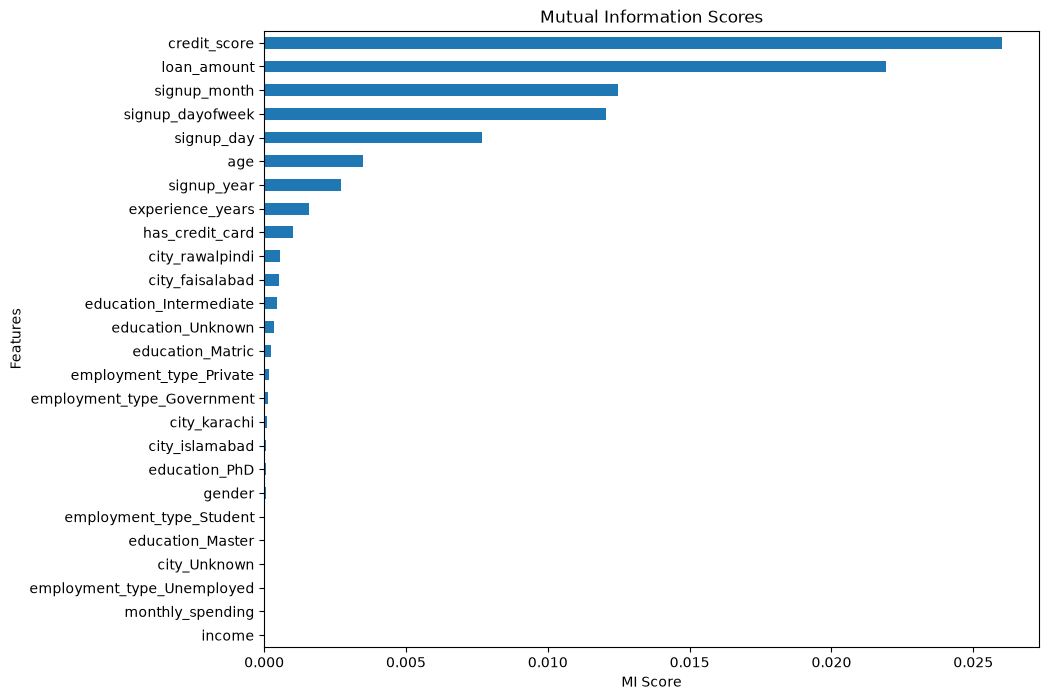

In [14]:
import matplotlib.pyplot as plt

mi_scores.sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Mutual Information Scores")
plt.xlabel("MI Score")
plt.ylabel("Features")
plt.show()

In [15]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# 1. Separate features and target
X = df.drop("defaulted", axis=1)
y = df["defaulted"]

# 2. Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# 3. Train model
model.fit(X, y)

# 4. Get feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# 5. Display importance
print(importance)

credit_score                  0.133035
loan_amount                   0.117430
income                        0.109155
monthly_spending              0.093520
experience_years              0.082149
signup_day                    0.076835
age                           0.073581
signup_month                  0.054998
signup_dayofweek              0.045551
signup_year                   0.043695
gender                        0.014014
has_credit_card               0.013011
employment_type_Government    0.012304
education_Master              0.012263
city_karachi                  0.012171
employment_type_Unemployed    0.011975
education_Matric              0.011730
city_rawalpindi               0.011579
employment_type_Private       0.011465
employment_type_Student       0.011291
education_Intermediate        0.011088
city_faisalabad               0.010455
city_islamabad                0.010436
education_PhD                 0.009945
city_Unknown                  0.004000
education_Unknown        

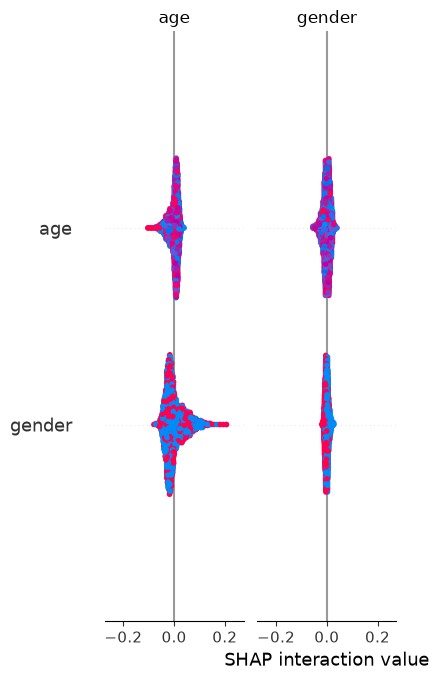

In [16]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X)

# Feature importance plot
shap.summary_plot(shap_values, X)

In [17]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer(X)

print(shap_values.shape)
print(X.shape)

(2432, 26, 2)
(2432, 26)


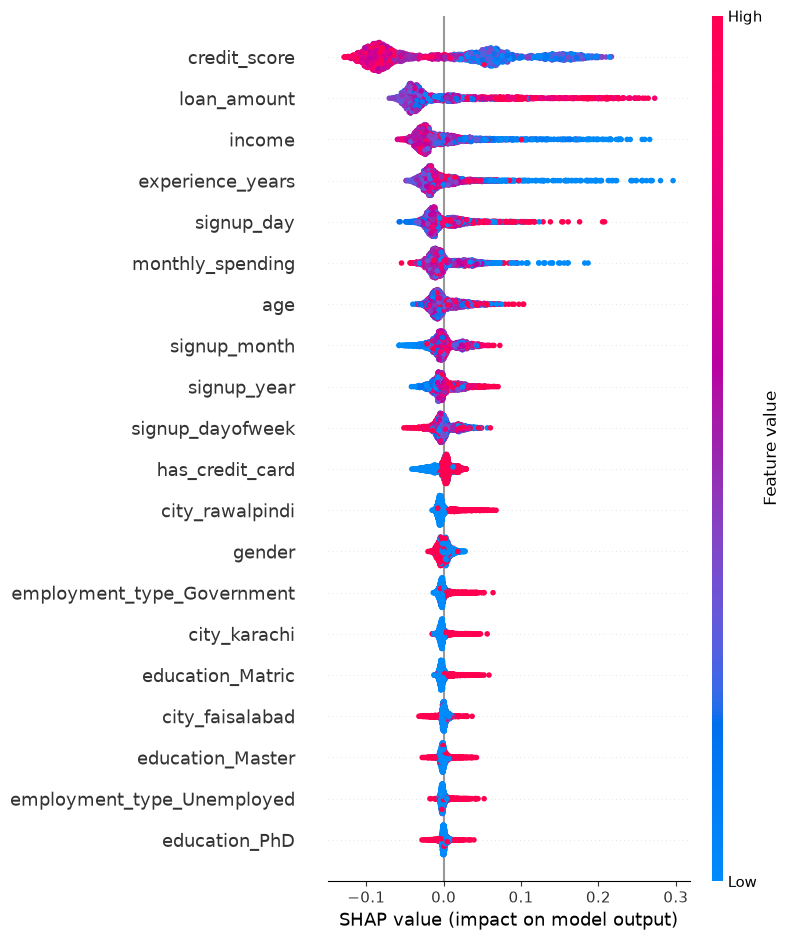

In [19]:
# Select SHAP values for class 1
shap_values_class1 = shap_values[:, :, 1]

# Plot top 20 features
shap.summary_plot(
    shap_values_class1,
    X,
    max_display=20
)

In [21]:
# Get actual SHAP numerical values
shap_array = shap_values.values

# Select class 1
shap_class1 = shap_array[:, :, 1]

# Calculate mean absolute SHAP importance
shap_importance = pd.Series(
    abs(shap_class1).mean(axis=0),
    index=X.columns
).sort_values(ascending=False)

print(shap_importance)

credit_score                  0.080066
loan_amount                   0.048412
income                        0.031649
experience_years              0.025254
signup_day                    0.020157
monthly_spending              0.017106
age                           0.014210
signup_month                  0.012813
signup_year                   0.011760
signup_dayofweek              0.010114
has_credit_card               0.009038
city_rawalpindi               0.007106
gender                        0.005142
employment_type_Government    0.005070
city_karachi                  0.004916
education_Matric              0.004878
city_faisalabad               0.003837
education_Master              0.003677
employment_type_Unemployed    0.003335
education_PhD                 0.003011
city_islamabad                0.002900
employment_type_Student       0.002835
education_Intermediate        0.002826
employment_type_Private       0.002542
city_Unknown                  0.001161
education_Unknown        